**Multi-objective robust decision making (MORDM)**

4 steps based on assignment 9

## Step 1: Problem formulation

In [126]:
import os
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import networkx as nx
import multiprocessing
import pickle

# Import EMA Workbench for exploratory modelling and analysis
from ema_workbench import (Policy, ema_logging, MultiprocessingEvaluator, save_results, Scenario, Constraint,
                            ScalarOutcome, Constant, perform_experiments)

from dike_model_function import DikeNetwork
from problem_formulation import get_model_for_problem_formulation, sum_over, sum_over_time

from ema_workbench.em_framework.salib_samplers import get_SALib_problem
from ema_workbench.em_framework.samplers import sample_uncertainties

from ema_workbench.em_framework.optimization import (HyperVolume, EpsilonProgress, ArchiveLogger, to_problem)
from ema_workbench.em_framework.evaluators import (BaseEvaluator, SequentialEvaluator)
from ema_workbench.analysis import parcoords, pairs_plotting    # Create parallel coordinate plots

from collections import OrderedDict

from ema_workbench.util.utilities import (save_results, load_results)
from ema_workbench.analysis import prim

In [ ]:
dike_model, planning_steps = get_model_for_problem_formulation(2)

# Don't minimize rfr, the costs can be as high as necessary
# Change direction only for "RfR Investment Costs"
#for outcome in dike_model.outcomes:
    #if outcome.name == "RfR Investment Costs":
        #utcome.kind = ScalarOutcome.INFO

In [128]:
# Check if the change worked and the other directions are still minimizing
for outcome in dike_model.outcomes:
    print(f"Outcome: {outcome.name}, Direction: {outcome.kind}")

Outcome: Expected Annual Damage, Direction: -1
Outcome: Dike Investment Costs, Direction: -1
Outcome: RfR Investment Costs, Direction: -1
Outcome: Evacuation Costs, Direction: -1
Outcome: Expected Number of Deaths, Direction: -1


## Step 2: Searching for candidate solutions

In [129]:
reference_scenario = Scenario('reference', **{'discount rate 0': 2.5, 'discount rate 1': 2.5, 'discount rate 2': 2.5, 'A.0_ID flood wave shape': 75,
                                              'A.1_Bmax': 190, 'A.1_pfail': 0.5, 'A.1_Brate': 1.5,
                                              'A.2_Bmax': 190, 'A.2_pfail': 0.5, 'A.2_Brate': 1.5,
                                              'A.3_Bmax': 190, 'A.3_pfail': 0.5, 'A.3_Brate': 1.5,
                                              'A.4_Bmax': 190, 'A.4_pfail': 0.5, 'A.4_Brate': 1.5,
                                              'A.5_Bmax': 190, 'A.5_pfail': 0.5, 'A.5_Brate': 1.5})

# Define constrains
# expected_annual_damage_limit = 60000000     # expecred annual damage
dike_investment_costs_limit = 189926453     # dike investment 
rfr_investment_costs_limit = 710400000      # RfR investment

constraints = [
    # Constraint("Expected Annual Damage", outcome_names="Expected Annual Damage",
    #            function=lambda x: max(0, x - expected_annual_damage_limit)),
    Constraint("Dike Investment Costs", outcome_names="Dike Investment Costs",
               function=lambda x: max(0, x - dike_investment_costs_limit)),
    Constraint("RfR Investment Costs", outcome_names="RfR Investment Costs",
               function=lambda x: max(0, x - rfr_investment_costs_limit))
    # Constraint('Expected Number of Deaths', outcome_names='Expected Number of Deaths',
    #            function=lambda x: max(0, x - 0.1))
]


In [130]:
ema_logging.log_to_stderr(ema_logging.INFO)

convergence_metric = [EpsilonProgress()]
epsilons = [0.25] * len([o for o in dike_model.outcomes if o.kind != ScalarOutcome.INFO])

with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.optimize(nfe=10000, searchover="levers", epsilons=epsilons, convergence= convergence_metric,reference=reference_scenario)

[MainProcess/INFO] pool started with 8 workers
100%|████████████████████████████████████| 10000/10000 [05:40<00:00, 29.37it/s]
[MainProcess/INFO] optimization completed, found 126 solutions
[MainProcess/INFO] terminating pool


In [142]:
archive, convergence = results
print(len(archive))

126


<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
/var/folders/xg/ppc27clj7h73rs0j46rpk57c0000gn/T/ipykernel_24755/4267563080.py:6: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('$\epsilon$-progress')


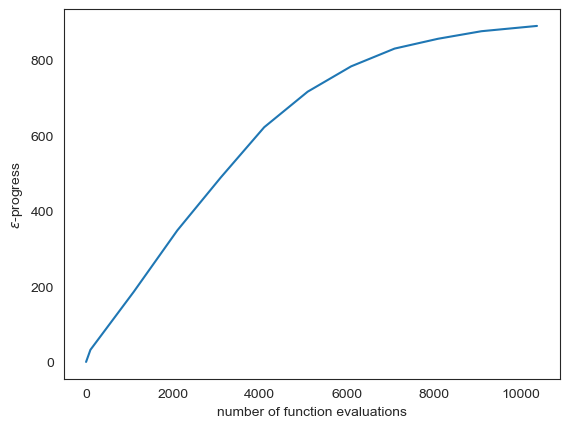

In [143]:
import matplotlib.pyplot as plt
import numpy as np
archive, convergence = results
fig, ax = plt.subplots()
ax.plot(convergence.nfe, convergence.epsilon_progress)
ax.set_ylabel('$\epsilon$-progress')

ax.set_xlabel('number of function evaluations')
plt.show()

In [144]:
results

(     0_RfR 0  0_RfR 1  0_RfR 2  1_RfR 0  1_RfR 1  1_RfR 2  2_RfR 0  2_RfR 1  \
 0          0        0        0        0        0        0        0        1   
 1          0        0        0        0        0        0        1        1   
 2          0        0        0        0        0        0        1        0   
 3          0        0        0        0        0        0        0        1   
 4          0        0        0        0        0        0        0        1   
 ..       ...      ...      ...      ...      ...      ...      ...      ...   
 121        0        0        0        0        0        0        0        0   
 122        0        0        0        0        0        0        0        0   
 123        0        0        0        0        0        0        0        0   
 124        0        0        1        0        0        0        1        1   
 125        0        1        0        0        0        0        0        0   
 
      2_RfR 2  3_RfR 0  ...  A.4_DikeI

In [145]:
outcomes, extra_info = results
outcomes

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,Expected Annual Damage,Dike Investment Costs,RfR Investment Costs,Evacuation Costs,Expected Number of Deaths
0,0,0,0,0,0,0,0,1,1,0,...,0,5,3,0,0,2.106733e+07,1.109750e+08,61400000.0,0.000000,0.019348
1,0,0,0,0,0,0,1,1,1,0,...,0,3,3,0,0,7.087204e+06,8.901611e+07,213300000.0,0.000000,0.006547
2,0,0,0,0,0,0,1,0,1,0,...,0,0,4,0,0,0.000000e+00,1.561628e+08,61400000.0,0.000000,0.000000
3,0,0,0,0,0,0,0,1,0,0,...,0,0,2,0,0,4.454115e+07,1.001002e+08,30700000.0,2362.110114,0.004876
4,0,0,0,0,0,0,0,1,1,0,...,0,0,3,0,0,7.216528e+06,1.486980e+08,61400000.0,0.000000,0.006782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1.014595e+08,5.931499e+07,0.0,0.000000,0.099043
122,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2.602103e+08,2.419803e+07,0.0,0.000000,0.189096
123,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2.739918e+08,2.029929e+07,0.0,0.000000,0.213448
124,0,0,1,0,0,0,1,1,0,0,...,0,0,2,0,0,2.880375e+07,2.757823e+07,267200000.0,1336.765579,0.003434


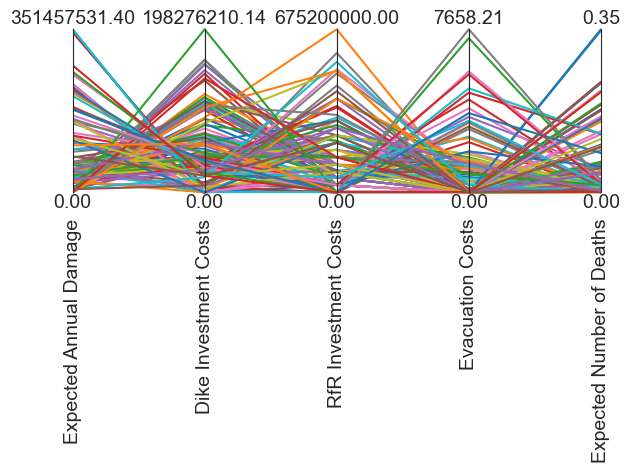

In [147]:
outcomes = outcomes.loc[:, [
    'Expected Annual Damage',
    'Dike Investment Costs',
    'RfR Investment Costs',
    'Evacuation Costs',
    'Expected Number of Deaths'
]]

limits = parcoords.get_limits(outcomes)
axes = parcoords.ParallelAxes(limits)
axes.plot(outcomes)

plt.show()

## Step 3: Re-evaluate candidate solutions under uncertainty

In [148]:
archive

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,Expected Annual Damage,Dike Investment Costs,RfR Investment Costs,Evacuation Costs,Expected Number of Deaths
0,0,0,0,0,0,0,0,1,1,0,...,0,5,3,0,0,2.106733e+07,1.109750e+08,61400000.0,0.000000,0.019348
1,0,0,0,0,0,0,1,1,1,0,...,0,3,3,0,0,7.087204e+06,8.901611e+07,213300000.0,0.000000,0.006547
2,0,0,0,0,0,0,1,0,1,0,...,0,0,4,0,0,0.000000e+00,1.561628e+08,61400000.0,0.000000,0.000000
3,0,0,0,0,0,0,0,1,0,0,...,0,0,2,0,0,4.454115e+07,1.001002e+08,30700000.0,2362.110114,0.004876
4,0,0,0,0,0,0,0,1,1,0,...,0,0,3,0,0,7.216528e+06,1.486980e+08,61400000.0,0.000000,0.006782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1.014595e+08,5.931499e+07,0.0,0.000000,0.099043
122,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2.602103e+08,2.419803e+07,0.0,0.000000,0.189096
123,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2.739918e+08,2.029929e+07,0.0,0.000000,0.213448
124,0,0,1,0,0,0,1,1,0,0,...,0,0,2,0,0,2.880375e+07,2.757823e+07,267200000.0,1336.765579,0.003434


In [151]:
logical = (archive['Expected Number of Deaths'] < 0.001) & (archive['RfR Investment Costs'] > 0)
print(np.sum(logical))

archive[logical]

policies = archive[logical]
policies


11


,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,Expected Annual Damage,Dike Investment Costs,RfR Investment Costs,Evacuation Costs,Expected Number of Deaths
2,0,0,0,0,0,0,1,0,1,0,...,0,0,4,0,0,0.000000e+00,1.561628e+08,61400000.0,0.000000,0.000000
11,0,1,0,0,0,0,0,0,1,0,...,0,1,4,0,0,1.518731e+06,1.195101e+08,115300000.0,0.000000,0.000854
24,0,1,0,0,0,0,0,0,1,0,...,0,7,4,0,0,0.000000e+00,1.551182e+08,115300000.0,0.000000,0.000000
25,0,0,1,0,0,0,0,0,1,0,...,0,0,3,0,0,0.000000e+00,1.108457e+08,236500000.0,0.000000,0.000000
27,0,0,0,0,0,0,0,0,1,0,...,0,1,4,0,0,0.000000e+00,1.612189e+08,30700000.0,0.000000,0.000000
29,0,0,1,0,0,0,0,0,0,0,...,0,0,3,0,0,7.401277e+06,1.147236e+08,84600000.0,386.148855,0.000854
61,0,1,0,0,0,0,1,1,1,0,...,0,1,3,0,0,0.000000e+00,9.105181e+07,675200000.0,0.000000,0.000000
107,0,1,1,0,0,0,0,1,0,0,...,0,1,2,0,0,6.257479e+06,1.059398e+08,321100000.0,338.882781,0.000473
109,0,1,0,0,0,0,1,1,1,1,...,0,1,0,0,0,7.013304e+06,1.854588e+07,540300000.0,371.674461,0.000770
111,0,1,1,0,0,0,1,1,1,0,...,0,1,4,0,0,0.000000e+00,1.034783e+08,503700000.0,0.000000,0.000000


In [152]:
from ema_workbench import Policy

policies_to_evaluate = []

for i, policy in policies.iterrows():
    policies_to_evaluate.append(Policy(str(i), **policy.to_dict()))
    
n_scenarios = 1000
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(n_scenarios,
                                            policies_to_evaluate)

results

[MainProcess/INFO] pool started with 8 workers



























































































































































































































































































































































































































































































































































































































































































































































































































































































































































































(       A.0_ID flood wave shape    A.1_Bmax A.1_Brate  A.1_pfail    A.2_Bmax  \
 0                           65  249.635827      10.0   0.757070  118.523982   
 1                          132   95.706564      10.0   0.315521   70.057960   
 2                           74  152.086787       1.5   0.243536  347.700477   
 3                           19  177.421116       1.5   0.704533  116.870628   
 4                           33  130.909628       1.5   0.714543  282.352161   
 ...                        ...         ...       ...        ...         ...   
 10995                       63  303.295360       1.5   0.406453  347.417011   
 10996                      107  342.967394       1.5   0.385570  335.621546   
 10997                        8  123.898551       1.0   0.013273  306.048650   
 10998                       67  211.616317       1.5   0.062181   42.431192   
 10999                      106  298.092024      10.0   0.599693  158.621718   
 
       A.2_Brate  A.2_pfail    A.3_Bma

In [ ]:
#save_results(results, 're_evaluation_results.tar.gz') We might need to save the results - I saw this in the example notebooks

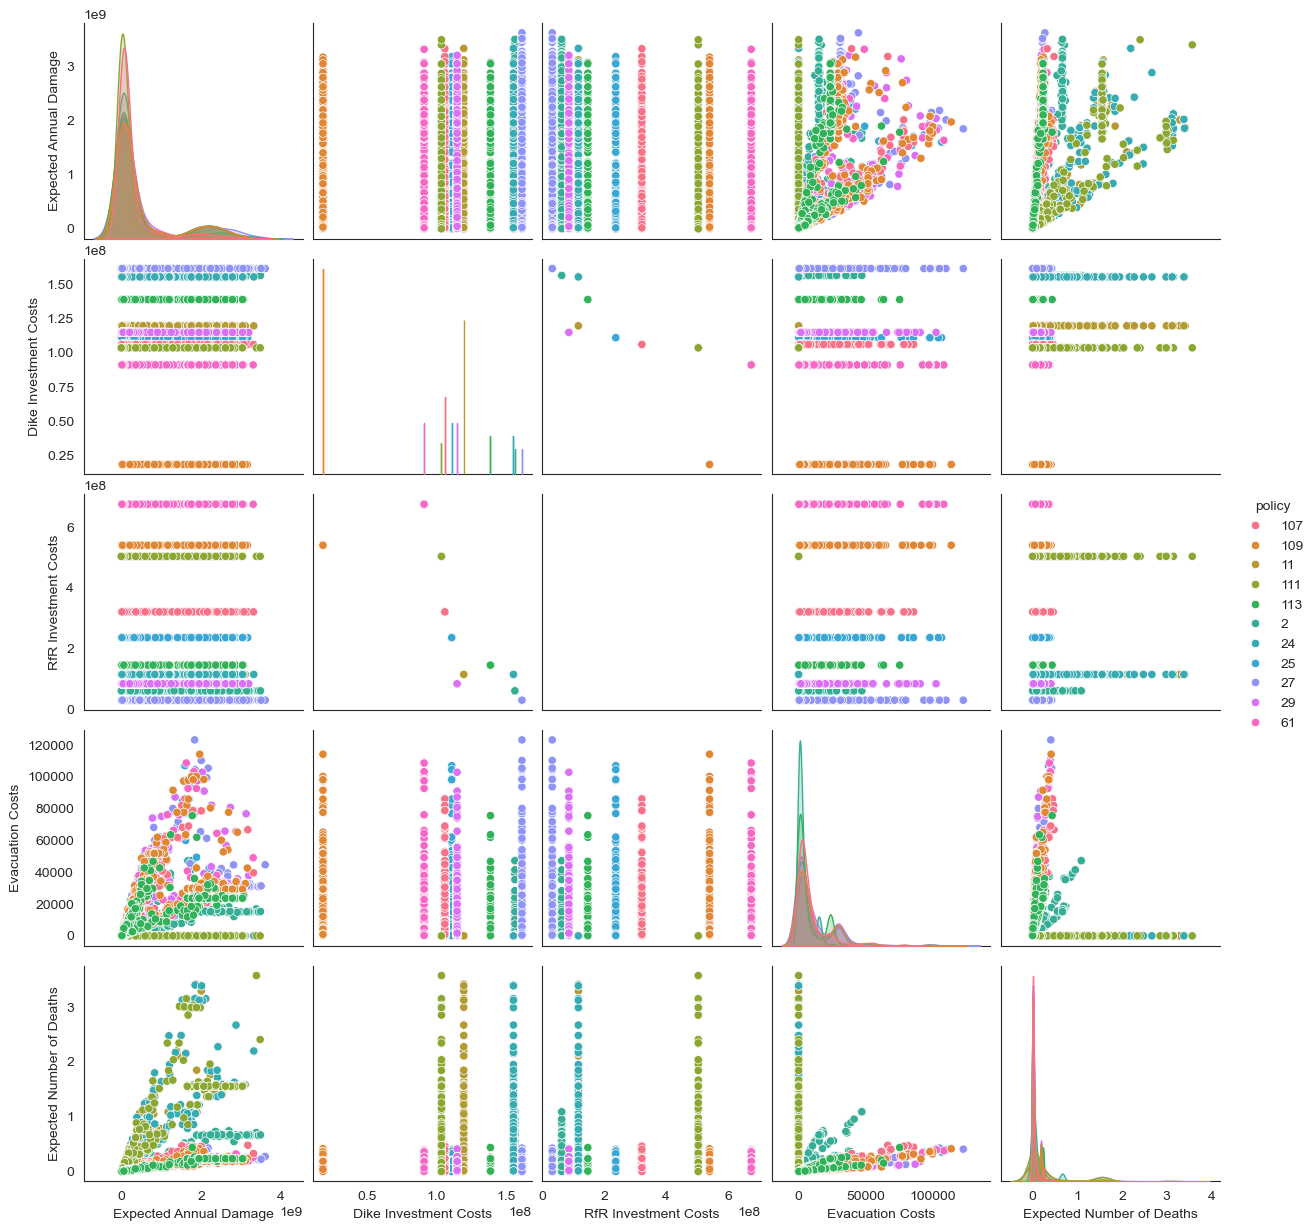

In [172]:
policies = experiments['policy']

data = pd.DataFrame.from_dict(outcomes)
data['policy'] = policies

sns.pairplot(data, hue='policy',  vars=outcomes.keys(), )
plt.show()

[MainProcess/INFO] column model dropped from analysis because it has only one category
[MainProcess/INFO] 11000 points remaining, containing 1404 cases of interest
[MainProcess/INFO] mean: 0.8582089552238806, mass: 0.060909090909090906, coverage: 0.40954415954415957, density: 0.8582089552238806 restricted_dimensions: 8


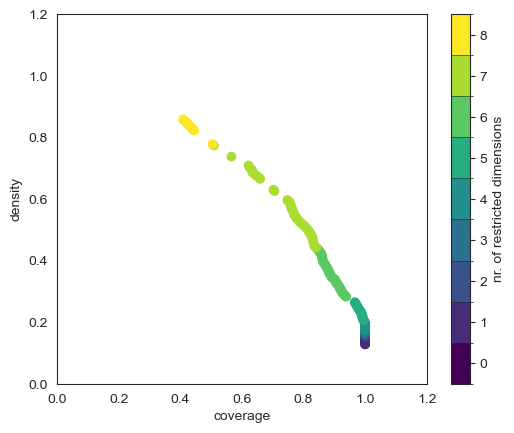

/opt/anaconda3/lib/python3.12/site-packages/ema_workbench/analysis/prim.py:501: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '{'111', '24', '107', '2', '113', '29', '61', '25', '109', '27'}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  box_lim.loc[unc] = values.values.tolist() + qp_values[unc]
/opt/anaconda3/lib/python3.12/site-packages/ema_workbench/analysis/prim.py:501: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '{'111', '24', '107', '2', '113', '29', '61', '25', '109', '27'}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  box_lim.loc[unc] = values.values.tolist() + qp_values[unc]


coverage       0.787037
density        0.526190
id           140.000000
k           1105.000000
mass           0.190909
mean           0.526190
n           2100.000000
res_dim        7.000000
Name: 140, dtype: float64

                                               box 140  \
                                                   min   
A.3_Bmax                                     30.313072   
A.3_pfail                                     0.358588   
A.1_pfail                                     0.300996   
A.5_pfail                                     0.317484   
A.2_pfail                                     0.282224   
A.4_pfail                                     0.091341   
policy     {111, 24, 107, 2, 113, 29, 61, 25, 109, 27}   

                                                                                
                                                   max      qp value  qp value  
A.3_Bmax                                    348.177567           NaN  0.329097  
A.3_pfail      

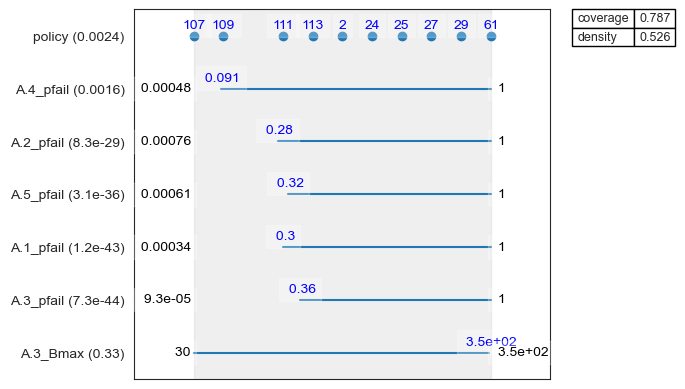

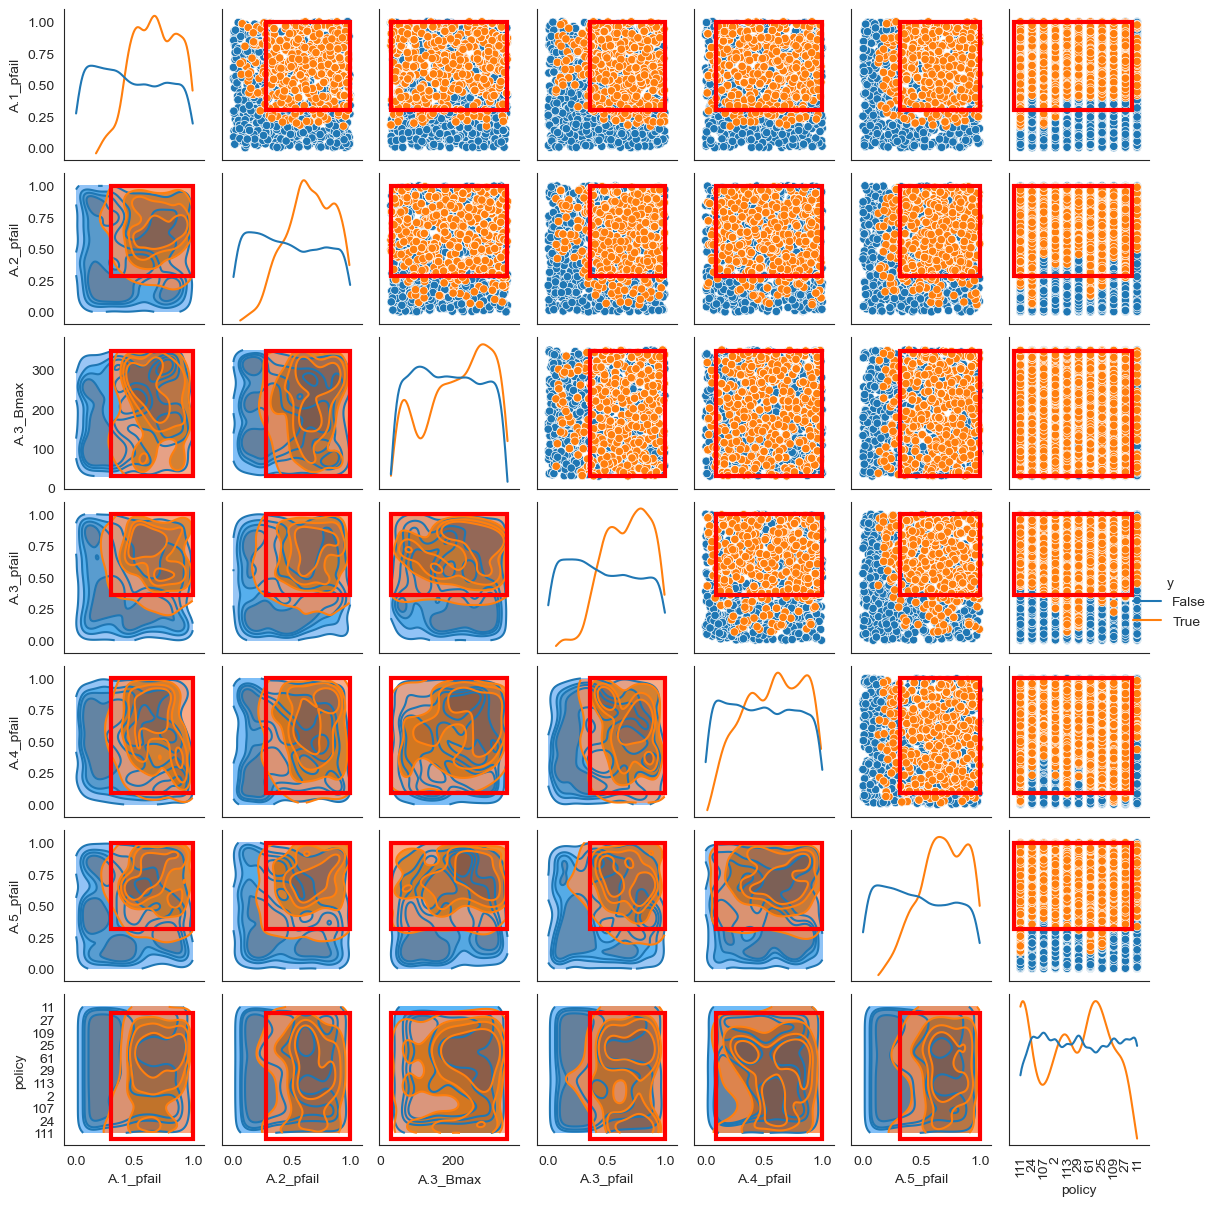

In [ ]:
# Clean the experiments for PRIM analysis
experiments_noDI = experiments.drop(labels=[
    'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2',
    'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2',
    'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2',
    'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2',
    'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2', 
    'policy'
], axis=1)

cleaned_experiments = experiments.drop(labels=[
    '0_RfR 0', '0_RfR 1', '0_RfR 2',
    '1_RfR 0', '1_RfR 1', '1_RfR 2',
    '2_RfR 0', '2_RfR 1', '2_RfR 2',
    '3_RfR 0', '3_RfR 1', '3_RfR 2',
    '4_RfR 0', '4_RfR 1', '4_RfR 2',
    'EWS_DaysToThreat'
], axis=1)

y = (
    (outcomes['Expected Number of Deaths'] < 0.001)
)


# Perform PRIM analysis
prim_alg = prim.Prim(cleaned_experiments, y, threshold=0.5, peel_alpha=0.01)
box = prim_alg.find_box()


# Visualize PRIM results
box.show_tradeoff()
plt.savefig('prim_tradeoff_density_coverage.png')
plt.show()

box.inspect(140)
box.inspect(140, style='graph')
plt.savefig('prim_ranges_of_uncertainties.png')
plt.show()

box.select(140)
box.show_pairs_scatter()
fig = plt.gcf()
fig.set_size_inches(12, 12)
plt.savefig('prim_scatter_plots.png')
plt.show()

In [169]:
def s_to_n(data, direction):
    mean = np.mean(data)
    std = np.std(data)
    
    if direction==ScalarOutcome.MAXIMIZE:
        return mean/std
    else:
        return mean*std
    

In [170]:
experiments, outcomes = results

overall_scores = {}
for policy in np.unique(experiments['policy']):
    scores = {}
    
    logical = experiments['policy']==policy
    
    for outcome in dike_model.outcomes:
        value  = outcomes[outcome.name][logical]
        sn_ratio = s_to_n(value, outcome.kind)
        scores[outcome.name] = sn_ratio
    overall_scores[policy] = scores
scores = pd.DataFrame.from_dict(overall_scores).T
scores

,Expected Annual Damage,Dike Investment Costs,RfR Investment Costs,Evacuation Costs,Expected Number of Deaths
107,1.448872e+17,1.578625,0.0,9.249627e+07,0.002617
109,4.123225e+17,0.069089,0.0,1.909768e+08,0.003423
11,4.191677e+17,1.780839,0.0,0.000000e+00,0.268161
111,1.197640e+17,1.541947,0.0,0.000000e+00,0.109887
113,3.575388e+17,0.000000,0.0,6.492309e+07,0.003792
2,2.492960e+17,4.654013,0.0,2.556184e+07,0.019898
24,3.983535e+17,9.245764,0.0,0.000000e+00,0.255584
25,3.921211e+17,3.303458,0.0,1.552803e+08,0.003331
27,4.965687e+17,0.000000,0.0,1.971673e+08,0.004660
29,4.139173e+17,6.838058,0.0,1.874143e+08,0.002955


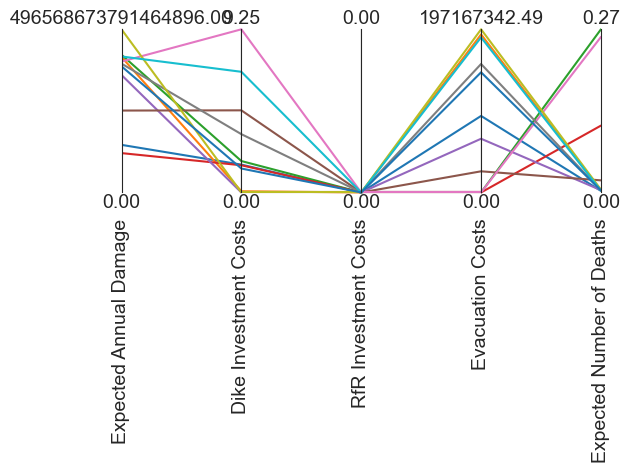

In [171]:
from ema_workbench.analysis import parcoords

data = scores
limits = parcoords.get_limits(data)
limits.loc[0, [
    'Expected Annual Damage',
    'Dike Investment Costs',
    'RfR Investment Costs',
    'Evacuation Costs',
    'Expected Number of Deaths'
]] = 0

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(data)
plt.show()

In [157]:
def calculate_regret(data, best):
    return np.abs(best-data)

In [159]:
experiments, outcomes = results

overall_regret = {}
max_regret = {}
for outcome in dike_model.outcomes:
    policy_column = experiments['policy']
    
    # create a DataFrame with all the relevent information
    # i.e., policy, scenario_id, and scores
    data = pd.DataFrame({outcome.name: outcomes[outcome.name], 
                         "policy":experiments['policy'],
                         "scenario":experiments['scenario']})
    
    # reorient the data by indexing with policy and scenario id
    data = data.pivot(index='scenario', columns='policy')
    
    # flatten the resulting hierarchical index resulting from 
    # pivoting, (might be a nicer solution possible)
    data.columns = data.columns.get_level_values(1)
    
    # we need to control the broadcasting. 
    # max returns a 1d vector across scenario id. By passing
    # np.newaxis we ensure that the shape is the same as the data
    # next we take the absolute value
    #
    # basically we take the difference of the maximum across 
    # the row and the actual values in the row
    #
    outcome_regret = (data.max(axis=1).values[:, np.newaxis] - data).abs()
    
    overall_regret[outcome.name] = outcome_regret
    max_regret[outcome.name] = outcome_regret.max()
    

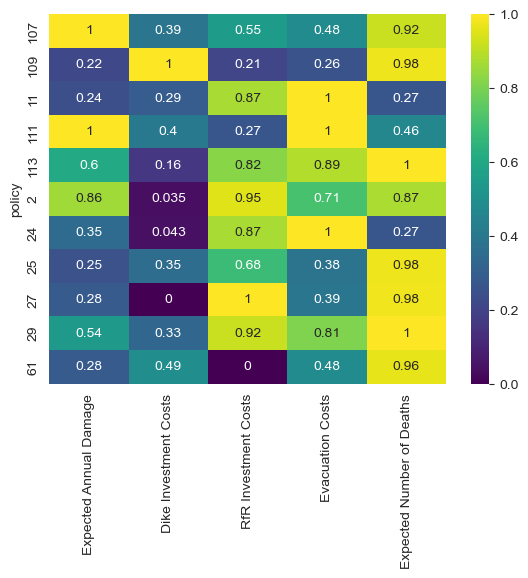

In [160]:
import seaborn as sns

max_regret = pd.DataFrame(max_regret)
sns.heatmap(max_regret/max_regret.max(), cmap='viridis', annot=True)
plt.show()

IndexError: list index out of range

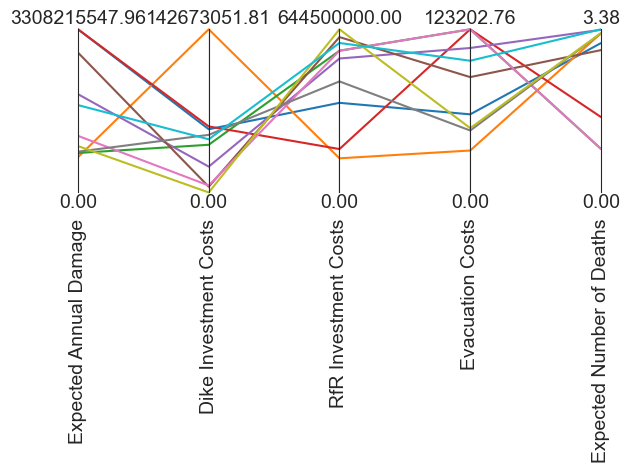

In [161]:

colors = sns.color_palette()

data = max_regret

# makes it easier to identify the policy associated with each line
# in the parcoords plot
# data['policy'] = data.index.astype("float64")

limits = parcoords.get_limits(data)
limits.loc[0, [
    'Expected Annual Damage',
    'Dike Investment Costs',
    'RfR Investment Costs',
    'Evacuation Costs',
    'Expected Number of Deaths'
]] = 0

paraxes = parcoords.ParallelAxes(limits)
for i, (index, row) in enumerate(data.iterrows()):
    paraxes.plot(row.to_frame().T, label=str(index), color=colors[i])
paraxes.legend()
    
plt.show()

In [163]:
from collections import defaultdict

policy_regret = defaultdict(dict)
for key, value in overall_regret.items():
    for policy in value:
        policy_regret[policy][key] = value[policy]

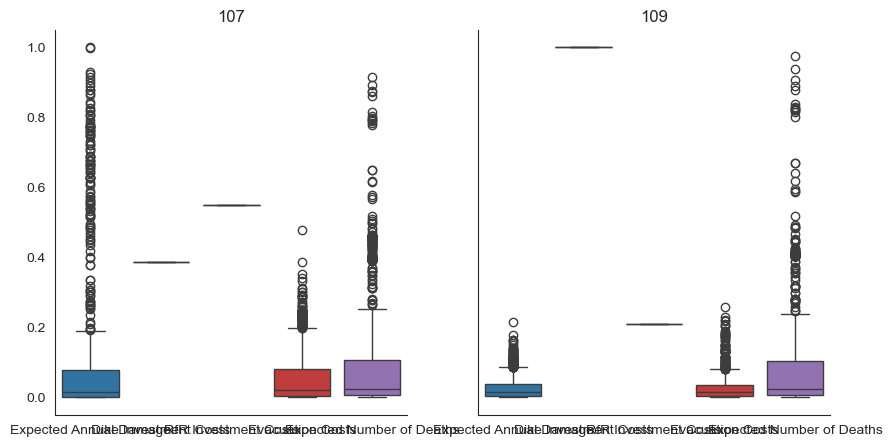

In [164]:
# this generates a 2 plots with a shared y and x axis
fig, axes = plt.subplots(ncols=2, figsize=(10,5), 
                         sharey=True, sharex=True)

# to ensure easy iteration over the axes grid, we turn it
# into a list. Because there are four plots, I hard coded
# this. 


# zip allows us to zip together the list of axes and the list of 
# key value pairs return by items. If we iterate over this
# it returns a tuple of length 2. The first item is the ax
# the second items is the key value pair.
for ax, (policy, regret) in zip(axes, policy_regret.items()):
    data = pd.DataFrame(regret)

    # we need to scale the regret to ensure fair visual
    # comparison. We can do that by divding by the maximum regret
    data = data/max_regret.max(axis=0)
    sns.boxplot(data=data, ax=ax)
    
    # removes top and left hand black outline of axes
    sns.despine()
    
    # ensure we know which policy the figure is for
    ax.set_title(str(policy))
plt.show()

## Step 4: Using scenario discovery to detect the vulnerabilities of the candidate solutions and improving the candidate solutions